## Evaluation on Test Set

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from tqdm.notebook import tqdm
from models import GraphLFNO

# --- 1. CONFIGURAZIONE ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)

output_dir = 'results_LFNO'
config_path = os.path.join(output_dir, 'config_lfno.json')

if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config file not found at {config_path}. Run train_LFNO.py first!")

with open(config_path, 'r') as f:
    config = json.load(f)

dt = config["DT"]
epsilon = config["EPSILON"]
modes = config["modes"]
width = config["width"]

# --- 2. CARICAMENTO DATI TEST ---
print("Loading Test Data...")
if not os.path.exists('data/data_ac_graph_test.npy'):
    raise FileNotFoundError("Test data not found!")

sol_np = np.load('data/data_ac_graph_test.npy') 
graph_info = np.load('data/graph_info.npz')

eigenvalues_np = graph_info['eigenvalues']
eigenvectors_np = graph_info['eigenvectors']

# MODIFICA OOM: Teniamo 'sol' sulla CPU (RAM di sistema)
sol = torch.tensor(sol_np, dtype=torch.float32)

# Phi e eigen servono al modello, li mettiamo su GPU
Phi = torch.tensor(eigenvectors_np, dtype=torch.float32).to(device)
eigen = torch.tensor(eigenvalues_np, dtype=torch.float32).to(device)

num_test_samples = sol.shape[0]
num_steps = sol.shape[1] - 1
print(f"Test Data Shape: {sol.shape}")
print(f"Simulation Steps: {num_steps}")

Using device: cuda:0
Loading Test Data...
Test Data Shape: torch.Size([2000, 21, 100])
Simulation Steps: 20


In [8]:
import torch
import numpy as np
import os
from collections import OrderedDict
from tqdm.notebook import tqdm

# --- 3. CARICAMENTO MODELLO ---
net = GraphLFNO(modes=modes, width=width, eigenvectors=Phi).to(device)
model_path = os.path.join(output_dir, 'lfno_model.pth')

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Modello non trovato in: {model_path}")

print(f"Caricamento modello da: {model_path}")
checkpoint = torch.load(model_path, map_location=device)

# --- GESTIONE CHECKPOINT ---
used_epsilon = epsilon 

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
    if 'epsilon' in checkpoint:
        learned_eps = checkpoint['epsilon']
        used_epsilon = learned_eps
        print(f"--> [INFO] Using LEARNED Epsilon: {learned_eps:.4f} (True: {epsilon})")
else:
    state_dict = checkpoint

# --- PULIZIA CHIAVI ---
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("_orig_mod.", "") 
    clean_state_dict[name] = v

net.load_state_dict(clean_state_dict)
net.eval()

print("LFNO Model loaded successfully. Running evaluation loop in batches...")

# Funzione ausiliaria inalterata
def get_residual_error(u_curr, u_next, net_pred, dt, eps, eigen, Phi):
    u_c_spec = u_curr @ Phi
    u_n_spec = u_next @ Phi
    deriv_spec = (u_n_spec - u_c_spec)/dt + eps**2 * u_n_spec * eigen
    deriv_phys = deriv_spec @ Phi.T
    return torch.norm(net_pred - deriv_phys, p=2, dim=1).mean().item()

denom = (1 + used_epsilon**2 * dt * eigen)

# MODIFICA OOM: Parametri per il batching
BATCH_SIZE = 64
n_batches = int(np.ceil(num_test_samples / BATCH_SIZE))

all_preds_cpu = []
loss_res_list = []

with torch.no_grad():
    # Iteriamo sui batch per non esplodere la VRAM
    for b in tqdm(range(n_batches), desc="Evaluating Batches"):
        start_idx = b * BATCH_SIZE
        end_idx = min((b + 1) * BATCH_SIZE, num_test_samples)
        
        # Estraiamo il batch e lo spostiamo su GPU
        sol_batch = sol[start_idx:end_idx].to(device)
        u_current = sol_batch[:, 0, :]
        
        # Salviamo la traiettoria su CPU per liberare la GPU
        trajectory_tensor = [u_current.cpu()]
        
        for step in range(num_steps):
            nonlinearity_phys = net(u_current)
            
            u_true_next = sol_batch[:, step+1, :]
            res_err = get_residual_error(u_current, u_true_next, nonlinearity_phys, dt, epsilon, eigen, Phi)
            loss_res_list.append(res_err)
            
            nonlin_spec = nonlinearity_phys @ Phi
            u_curr_spec = u_current @ Phi
            
            u_next_spec = (u_curr_spec + dt * nonlin_spec) / denom
            u_next_phys = u_next_spec @ Phi.T
            
            # Appendo alla CPU
            trajectory_tensor.append(u_next_phys.cpu())
            u_current = u_next_phys
            
        # Stack delle predizioni del batch corrente: (Batch_size, Time, Nodes)
        batch_preds = torch.stack(trajectory_tensor, dim=1)
        all_preds_cpu.append(batch_preds)

    # Concatena tutti i batch in un unico grande tensore sulla CPU
    preds = torch.cat(all_preds_cpu, dim=0)
    
    # Calcolo Errore Traiettoria (eseguito interamente su CPU per sicurezza)
    diff = preds - sol
    flat_diff = diff.reshape(num_test_samples, -1)
    flat_true = sol.reshape(num_test_samples, -1)
    
    norm_diff = torch.norm(flat_diff, p=2, dim=1)
    norm_true = torch.norm(flat_true, p=2, dim=1)
    
    rel_errors = (norm_diff / (norm_true + 1e-6)).numpy()
    mean_res_error = np.mean(loss_res_list)

print("Evaluation complete.")

ValueError: Not enough eigenvectors provided! Got 100, needed 200

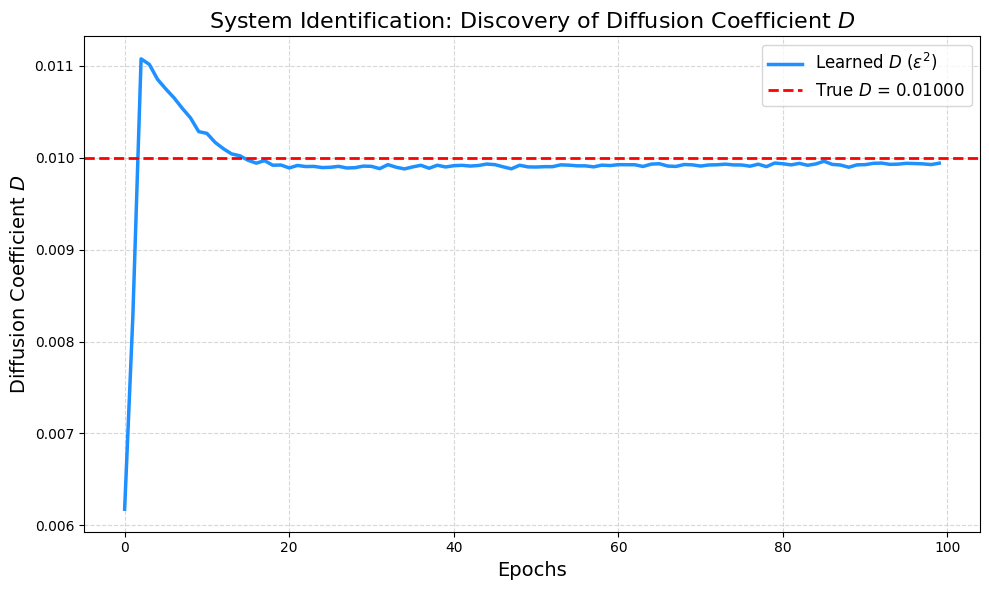

----------------------------------------
SYSTEM IDENTIFICATION REPORT
----------------------------------------
True Parameter D:    0.010000
Learned Parameter D: 0.009941
Relative Error:      0.59%
----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json

# --- 1. SETUP PATHS ---
# Assumiamo che 'output_dir' sia già definito dalle celle precedenti.
# Se no, decommenta la riga sotto:
# output_dir = 'results_LFNO'

eps_history_path = os.path.join(output_dir, 'epsilon_history_lfno.npy')
config_path = os.path.join(output_dir, 'config_lfno.json')

# --- 2. CARICAMENTO DATI ---
if os.path.exists(eps_history_path) and os.path.exists(config_path):
    # Carica la storia di epsilon
    eps_history = np.load(eps_history_path)
    
    # Carica il valore vero dal config
    with open(config_path, 'r') as f:
        config_train = json.load(f)
    true_eps = config_train['EPSILON']
    
    # Conversione: Il modello impara epsilon, ma il parametro fisico è D = epsilon^2
    D_history = eps_history ** 2
    true_D = true_eps ** 2
    epochs = np.arange(len(D_history))

    # --- 3. PLOT ---
    plt.figure(figsize=(10, 6))
    
    # Curva di apprendimento
    plt.plot(epochs, D_history, label='Learned $D$ ($\epsilon^2$)', color='dodgerblue', linewidth=2.5)
    
    # Linea Ground Truth
    plt.axhline(y=true_D, color='red', linestyle='--', linewidth=2, label=f'True $D$ = {true_D:.5f}')
    
    # Titoli e Label
    plt.title('System Identification: Discovery of Diffusion Coefficient $D$', fontsize=16)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel(r'Diffusion Coefficient $D$', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # --- 4. REPORT NUMERICO ---
    final_D = D_history[-1]
    err_percent = abs(final_D - true_D) / true_D * 100
    
    print("-" * 40)
    print("SYSTEM IDENTIFICATION REPORT")
    print("-" * 40)
    print(f"True Parameter D:    {true_D:.6f}")
    print(f"Learned Parameter D: {final_D:.6f}")
    print(f"Relative Error:      {err_percent:.2f}%")
    print("-" * 40)

else:
    print(f"⚠️ Attenzione: File history '{eps_history_path}' non trovato.")
    print("Hai eseguito il training con 'learn_D = True'?")

In [ ]:
# --- 4. REPORT SYSTEM IDENTIFICATION (D) ---

# Calcolo dei coefficienti di diffusione (D = epsilon^2)
true_D = epsilon ** 2
learned_D = used_epsilon ** 2

# Calcolo dell'errore percentuale relativo
# Formula: |Learned - True| / True * 100
d_error_percent = abs(learned_D - true_D) / (true_D + 1e-8) * 100

print("\n" + "="*50)
print("🔬 SYSTEM IDENTIFICATION REPORT: Diffusion Coefficient D")
print("="*50)
print(f"True Epsilon:       {epsilon:.6f}")
print(f"Learned Epsilon:    {used_epsilon:.6f}")
print("-" * 50)
print(f"True D (eps^2):     {true_D:.6f}")
print(f"Learned D (Best):   {learned_D:.6f}")
print("-" * 50)
print(f"📉 Error on D:        {d_error_percent:.4f}%")
print("="*50)


🔬 SYSTEM IDENTIFICATION REPORT: Diffusion Coefficient D
True Epsilon:       0.100000
Learned Epsilon:    0.099628
--------------------------------------------------
True D (eps^2):     0.010000
Learned D (Best):   0.009926
--------------------------------------------------
📉 Error on D:        0.7427%


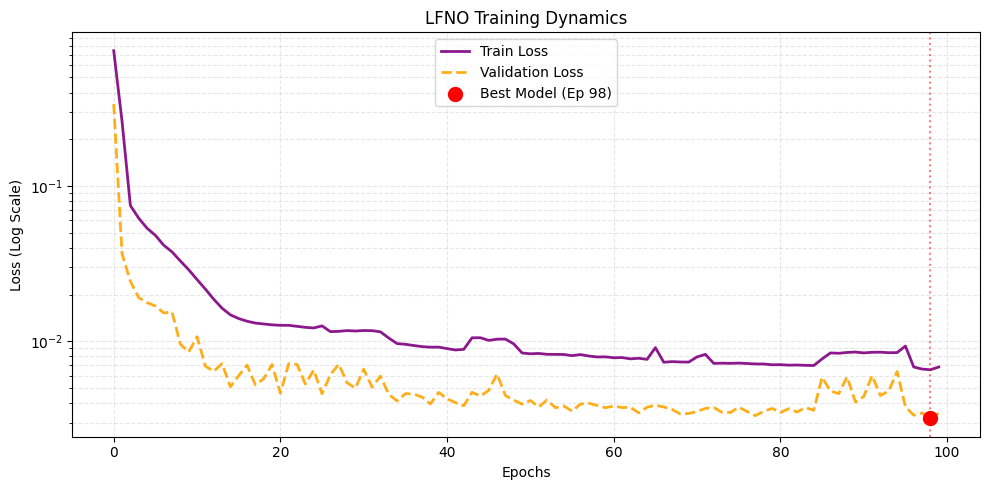

TEST SET RESULTS (LFNO)
Average Residual Loss (MSE): 1.91e+00
Best Validation Loss:        3.20e-03 (Ep 98)
Relative Trajectory Error:   0.0042 ± 0.0022
Accuracy (1 - RelErr):       99.58%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. LOAD TRAINING HISTORY ---
# Assicurati che 'output_dir' sia definito (es. 'results_LFNO')
loss_file_path = os.path.join(output_dir, 'loss_history.npy')
val_loss_file_path = os.path.join(output_dir, 'val_loss_history.npy')

if os.path.exists(loss_file_path):
    loss_history = np.load(loss_file_path)
    
    # Check if validation loss exists
    val_loss_history = None
    if os.path.exists(val_loss_file_path):
        val_loss_history = np.load(val_loss_file_path)

    # --- 2. PLOT TRAINING HISTORY (Stile Standardizzato) ---
    plt.figure(figsize=(10, 5))
    
    # Plot Training Loss
    plt.plot(loss_history, label='Train Loss', color='purple', alpha=0.9, linewidth=2)
    
    # Plot Validation Loss (se esiste)
    if val_loss_history is not None:
        plt.plot(val_loss_history, label='Validation Loss', color='orange', alpha=0.9, linewidth=2, linestyle='--')
        
        # Trova e segna il punto di minimo (Best Epoch)
        best_epoch = np.argmin(val_loss_history)
        best_val = val_loss_history[best_epoch]
        plt.scatter(best_epoch, best_val, color='red', s=100, zorder=5, label=f'Best Model (Ep {best_epoch})')
        plt.axvline(x=best_epoch, color='red', linestyle=':', alpha=0.5)

    plt.yscale('log')
    plt.title('LFNO Training Dynamics')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Log Scale)')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Attenzione: File loss non trovato in {loss_file_path}")

# --- 3. PRINT METRICS ---
if 'rel_errors' in locals():
    mean_traj_err = np.mean(rel_errors)
    std_traj_err = np.std(rel_errors)

    print("="*40)
    print("TEST SET RESULTS (LFNO)")
    print("="*40)
    
    if 'mean_res_error' in locals():
        print(f"Average Residual Loss (MSE): {mean_res_error:.2e}")
        
    if val_loss_history is not None:
        print(f"Best Validation Loss:        {np.min(val_loss_history):.2e} (Ep {np.argmin(val_loss_history)})")
        
    print(f"Relative Trajectory Error:   {mean_traj_err:.4f} ± {std_traj_err:.4f}")
    print(f"Accuracy (1 - RelErr):       {(1-mean_traj_err)*100:.2f}%")
    print("="*40)
else:
    print("⚠️ Variabile 'rel_errors' non trovata. Esegui la cella di valutazione precedente.")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- IMPOSTAZIONI ---
arch_name = "LFNO" 

# --- PLOT STANDARD ---
plt.figure(figsize=(10, 6))

# Istogramma con stile standard (skyblue)
sns.histplot(rel_errors, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Linea della media (formattata come percentuale)
plt.axvline(mean_traj_err, color='red', linestyle='--', linewidth=2, label=f'Avg: {mean_traj_err:.2%}')

# Titolo dinamico
plt.title(f'Distribution of RELATIVE L2 Errors ({arch_name})', fontsize=14)

# --- FONT SIZE & LABEL FIX ---
plt.xlabel('Relative Error', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.legend(fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# --- FIX SOVRAPPOSIZIONE (Notazione Scientifica) ---
# Forza la notazione scientifica (es. 9.5 invece di 0.00095)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# Ingrandisce il moltiplicatore (es. 1e-4) in basso a destra
plt.gca().xaxis.get_offset_text().set_fontsize(14)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

NameError: name 'rel_errors' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
import numpy as np

# --- CALCOLO STATISTICHE (LFNO) ---
errors_array = np.array(rel_errors)

stat_mean = np.mean(errors_array)
stat_std  = np.std(errors_array)
stat_min  = np.min(errors_array)
stat_max  = np.max(errors_array)

# --- STAMPA A VIDEO ---
print(f"--- DETAILED STATISTICS: {arch_name} (Topology-Informed) ---")
print(f"Count    : {len(errors_array)}")
print(f"Mean (μ) : {stat_mean:.4e}  ({stat_mean:.2%})")
print(f"Std  (σ) : {stat_std:.4e}   ({stat_std:.2%})")
print(f"Min      : {stat_min:.4e}   ({stat_min:.2%})")
print(f"Max      : {stat_max:.4e}   ({stat_max:.2%})")

print("-" * 40)
print("--- CLIPBOARD READY (For Report/Table) ---")
# Formato LaTeX ready: 7.52 x 10^-5
print(f"{arch_name} Result: {stat_mean:.2e} ± {stat_std:.2e}")

# Check rapido per te: ordine di grandezza
print(f"\n[Check] Log10 Mean Error: {np.log10(stat_mean):.2f}")

--- DETAILED STATISTICS: LFNO (Topology-Informed) ---
Count    : 2000
Mean (μ) : 4.2345e-03  (0.42%)
Std  (σ) : 2.2271e-03   (0.22%)
Min      : 1.3611e-03   (0.14%)
Max      : 1.8329e-02   (1.83%)
----------------------------------------
--- CLIPBOARD READY (For Report/Table) ---
LFNO Result: 4.23e-03 ± 2.23e-03

[Check] Log10 Mean Error: -2.37


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- CONFIGURAZIONE STILE (FONT GIGANTI & CLEAN) ---
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})

# Selezioniamo lo stesso indice usato per FNO per confronto diretto
sample_idx = 10 
print(f"Visualizing Sample Index: {sample_idx}")

# Estrazione dati
u_true_map = sol[sample_idx].cpu().numpy().T
u_pred_map = preds[sample_idx].cpu().numpy().T  # Qui 'preds' sono quelle del modello LFNO
u_err_map = np.abs(u_true_map - u_pred_map)

# --- CALCOLO PASSO PER GLI ASSI ---
num_nodes = u_true_map.shape[0]
num_time = u_true_map.shape[1]
y_step = max(1, num_nodes // 10) 
x_step = max(1, num_time // 10)

# --- LOGICA COLORI (Cruciale: Adattiva) ---
global_max = max(u_true_map.max(), u_pred_map.max())
global_min = min(u_true_map.min(), u_pred_map.min())

# Rilevamento automatico: se NON ci sono negativi, partiamo da 0
if global_min >= 0:
    vmin, vmax = 0.0, global_max
    print(f"Positives only detected: Colorbar [0.0, {vmax:.2f}]")
else:
    # Se ci sono negativi, usiamo scala simmetrica
    limit = max(abs(global_min), abs(global_max))
    vmin, vmax = -limit, limit
    print(f"Negatives detected: Colorbar [{-limit:.2f}, {limit:.2f}]")

# Setup grafico
fig, axes = plt.subplots(1, 3, figsize=(26, 7))

# Helper per parametri comuni
heatmap_args = {
    'vmin': vmin, 'vmax': vmax, 
    'cmap': 'RdBu_r', 
    'cbar': True,
    'xticklabels': x_step,
    'yticklabels': y_step
}

# 1. Ground Truth
sns.heatmap(u_true_map, ax=axes[0], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Node Index')

# 2. Prediction (LFNO)
sns.heatmap(u_pred_map, ax=axes[1], cbar_kws={'label': 'Concentration'}, **heatmap_args)
axes[1].set_title('LFNO Prediction') 
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Node Index')

# 3. Absolute Error (Scientific Notation)
mae = np.mean(u_err_map)
sns.heatmap(u_err_map, ax=axes[2], cmap='inferno', vmin=0, 
            xticklabels=x_step, yticklabels=y_step,
            cbar=True, cbar_kws={'label': 'Abs. Error'})

# FORMATTAZIONE SCIENTIFICA NEL TITOLO
axes[2].set_title(f'Mean Abs Error: {mae:.2e}') 
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Node Index')

# Rotazione tick
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# SPAZIATURA TRA I PLOT
plt.tight_layout(w_pad=3.0) 
plt.show()

Visualizing Sample Index: 10


NameError: name 'preds' is not defined

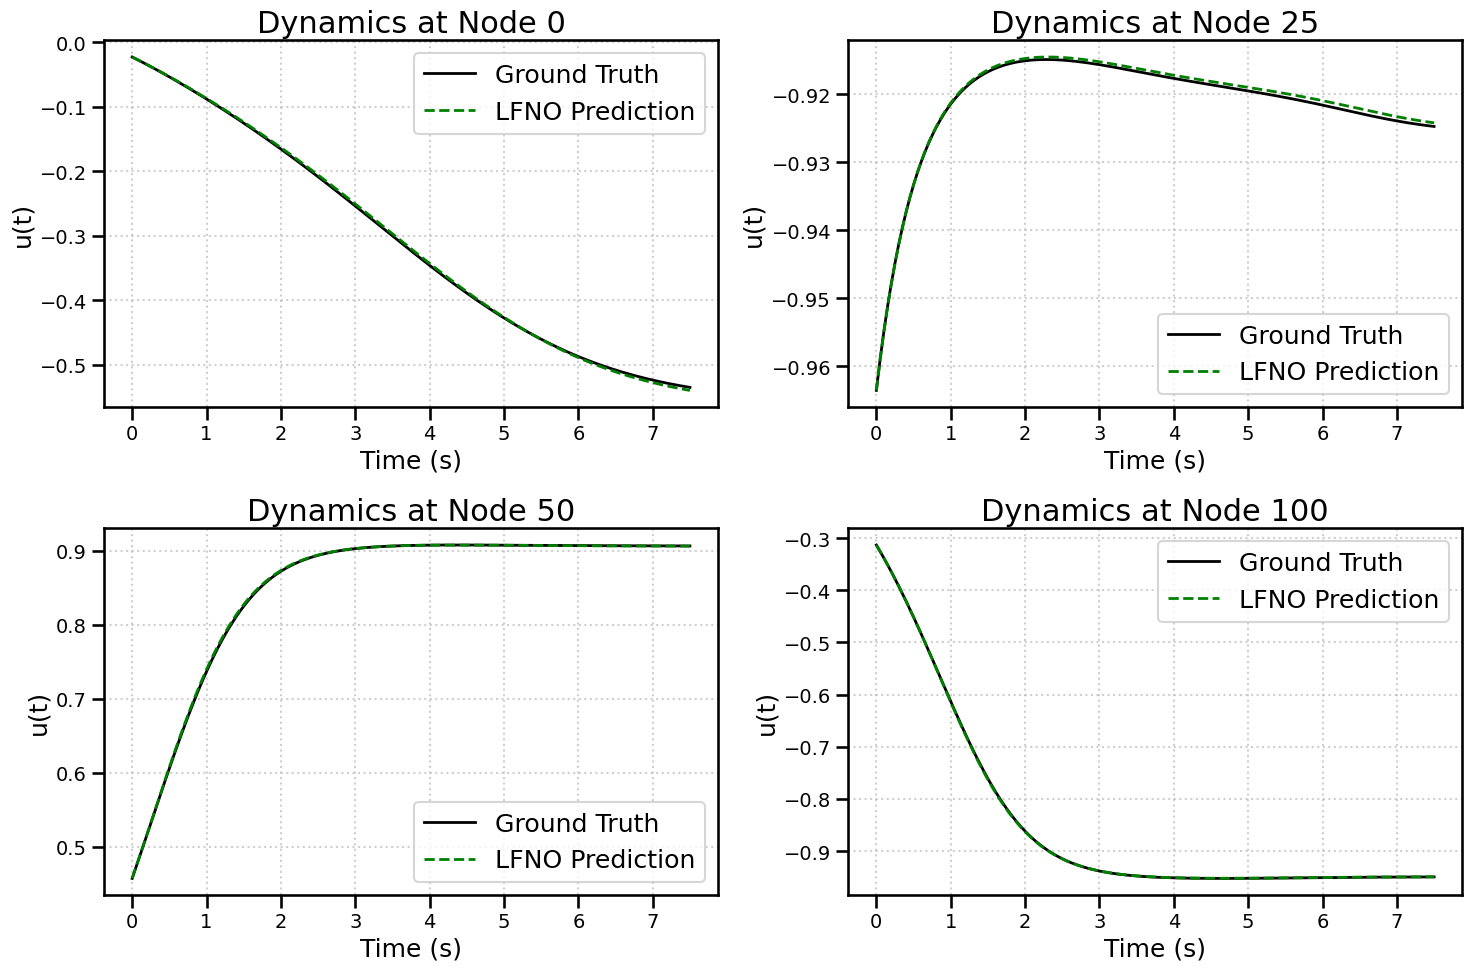

In [9]:
# --- NODE DYNAMICS PLOT ---
nodes_to_plot = [0, 25, 50, 100] 
time_axis = np.arange(num_steps + 1) * dt

plt.figure(figsize=(15, 10))

for i, node_idx in enumerate(nodes_to_plot):
    plt.subplot(2, 2, i+1)
    
    y_true = sol[sample_idx, :, node_idx].cpu().numpy()
    y_pred = preds[sample_idx, :, node_idx].cpu().numpy()
    
    plt.plot(time_axis, y_true, 'k-', linewidth=2, label='Ground Truth')
    plt.plot(time_axis, y_pred, 'g--', linewidth=2, label='LFNO Prediction') # Linea Verde per LFNO
    
    plt.title(f'Dynamics at Node {node_idx}')
    plt.xlabel('Time (s)')
    plt.ylabel('u(t)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

## Visualizzazione Dinamica Simulata

Loading configuration...
Loading dataset...


/tmp/ipykernel_208334/4111306932.py:92: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


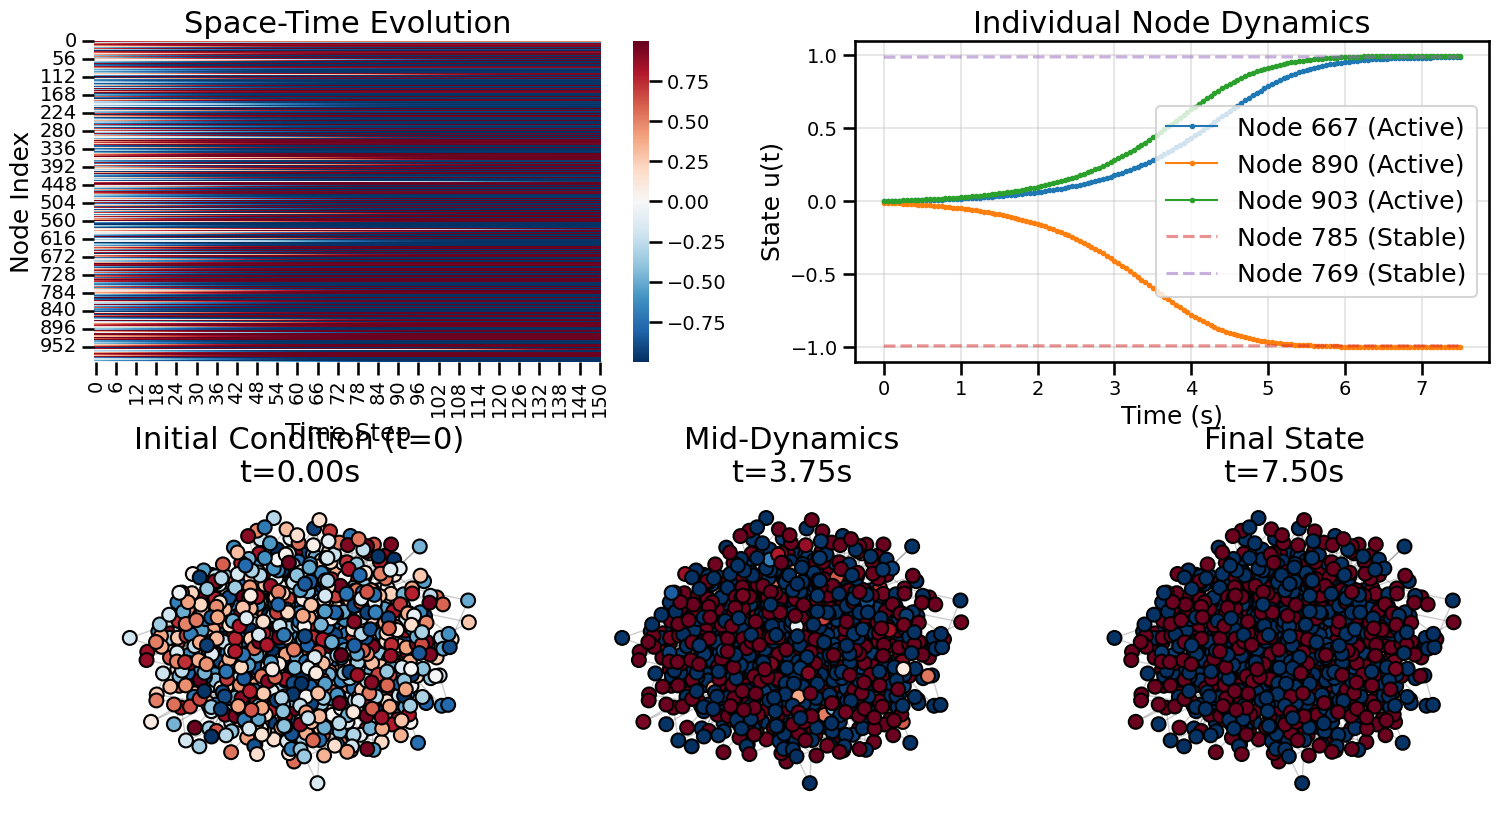

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import os
import json

# --- 1. Load Configuration & Data ---
print("Loading configuration...")
if not os.path.exists('data/config_data.json'):
    raise FileNotFoundError("Config file not found. Run generate_data.py first!")

with open('data/config_data.json', 'r') as f:
    config = json.load(f)

dt = config["DT"]
num_steps = config["NUM_STEPS"]

print("Loading dataset...")
# Carichiamo il dataset di TRAINING per visualizzare le simulazioni generate
data_file = 'data/data_ac_graph_train.npy' 

if not os.path.exists(data_file):
    raise FileNotFoundError(f"{data_file} not found. Run generate_data.py first!")

data = np.load(data_file)  # Shape: (N_samples, Time, Nodes)
graph_info = np.load('data/graph_info.npz')
L = graph_info['L']  # Laplacian Matrix

# Select a sample to visualize (e.g., the first one)
sample_idx = 0
trajectory = data[sample_idx]  # Shape: (Time, Nodes)
steps_in_traj, num_nodes = trajectory.shape

# Create time axis based on config
time_axis = np.linspace(0, (steps_in_traj-1) * dt, steps_in_traj)

# --- 2. Reconstruct Graph for Visualization ---
# We reconstruct the graph topology from the Laplacian matrix.
adj_matrix = np.where(L < 0, 1, 0) 
G = nx.from_numpy_array(adj_matrix)

# Pre-compute layout for consistent node positioning
pos = nx.spring_layout(G, seed=42) 

# --- Visualization ---
fig = plt.figure(figsize=(18, 10))

# A. Space-Time Heatmap
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(trajectory.T, ax=ax1, cmap='RdBu_r', center=0, cbar=True)
ax1.set_title("Space-Time Evolution")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Node Index")

# B. Single Node Trajectories
ax2 = plt.subplot(2, 2, 2)
variances = np.var(trajectory, axis=0)
active_nodes = np.argsort(variances)[-3:] # Top 3 active
stable_nodes = np.argsort(variances)[:2]  # Top 2 stable

for node in active_nodes:
    ax2.plot(time_axis, trajectory[:, node], 'o-', label=f'Node {node} (Active)', linewidth=1.5, markersize=3)

for node in stable_nodes:
    ax2.plot(time_axis, trajectory[:, node], '--', label=f'Node {node} (Stable)', alpha=0.5)

ax2.set_title("Individual Node Dynamics")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("State u(t)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# C. Graph Snapshots (Start, Middle, End)
times_to_plot_indices = [0, steps_in_traj // 2, steps_in_traj - 1]
titles = ["Initial Condition (t=0)", "Mid-Dynamics", "Final State"]

for i, t_idx in enumerate(times_to_plot_indices):
    ax = plt.subplot(2, 3, 4 + i) # Positions 4, 5, 6
    
    node_colors = trajectory[t_idx, :]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, 
                           node_color=node_colors, cmap='RdBu_r', 
                           vmin=-1, vmax=1, edgecolors='k')
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2)
    
    real_time = t_idx * dt
    ax.set_title(f"{titles[i]}\nt={real_time:.2f}s")
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- MODIFICA AGGIUNTA ---
# Aumenta lo spazio verticale (height space) tra le righe di plot
plt.subplots_adjust(hspace=0.4) 
# -------------------------

plt.show()

## Visualizzazione Apprendimento termine di reazione F(V) (Allen-Cahn)

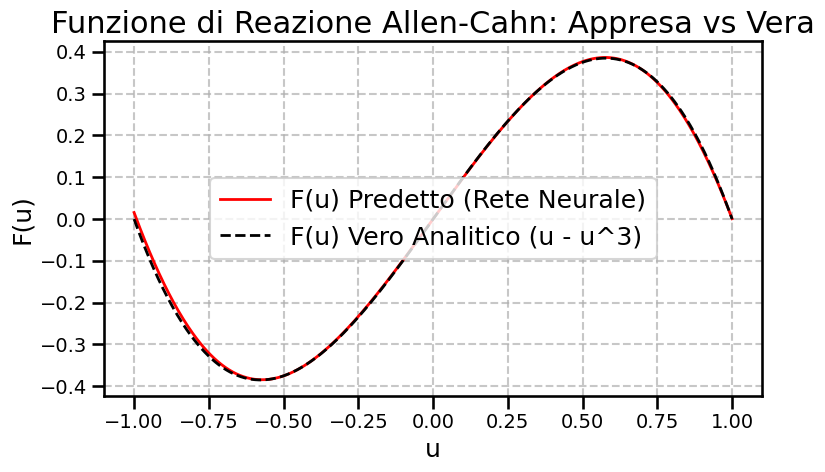

In [13]:
# --- 4. PLOT DELLA FUNZIONE DI REAZIONE APPRESA F(u) VS TRUE F(u) (ALLEN-CAHN) ---
# Estraiamo il numero di nodi dalla shape della soluzione di test
num_nodes = sol.shape[2]

# Definizione del range di u da esplorare. 
# Per Allen-Cahn, gli stati stabili sono -1 e 1, e 0 è instabile.
# Un range tra -1.5 e 1.5 mostra perfettamente la forma cubica.
u_min, u_max = -1.0,1.0
u_vals = torch.linspace(u_min, u_max, 500, device=device)

# Creiamo un tensore (Batch=500, Nodes=num_nodes)
u_test = u_vals.unsqueeze(1).repeat(1, num_nodes)

# Facciamo passare il tensore nella rete per ottenere la predizione della reazione
with torch.no_grad():
    f_pred_tensor = net(u_test)

# Estraiamo l'output per il plot
u_plot = u_vals.cpu().numpy()
f_plot = f_pred_tensor[:, 0].cpu().numpy()

# Calcoliamo il termine di reazione vero per Allen-Cahn
# Come da codice generatore: R(u) = u - u^3
f_true = u_plot - u_plot**3

# Creazione del plot
plt.figure(figsize=(8, 5))
plt.plot(u_plot, f_plot, label='F(u) Predetto (Rete Neurale)', color='red', linewidth=2)
plt.plot(u_plot, f_true, label='F(u) Vero Analitico (u - u^3)', color='black', linestyle='dashed', linewidth=2)
plt.title('Funzione di Reazione Allen-Cahn: Appresa vs Vera')
plt.xlabel('u')
plt.ylabel('F(u)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()